In [1]:
import glob
import os

import pandas as pd
import numpy as np

import tifffile as tf
from tifffile import imread
from tifffile import imwrite

import skimage
from skimage.util import compare_images
from skimage import io, color, measure
from skimage.measure import regionprops
from skimage.measure import label as sk_label  # Renaming the label function to avoid conflicts

import matplotlib.pyplot as plt
import matplotlib

%load_ext autoreload
%autoreload 2
%matplotlib inline


In [82]:
# Import masks

mask_cell_dir = '/Users/abamford/Desktop/TUBB2B-KI_preliminary_analysis/Batch20230922/D35/50ms/ROIs/Whole_cell/ROIs_as_mask_BIOP'
mask_cell_path = os.path.join(mask_cell_dir,'*.tif') 
mask_cell_files = glob.glob(mask_cell_path)

mask_nucleus_dir = '/Users/abamford/Desktop/TUBB2B-KI_preliminary_analysis/Batch20230922/D35/50ms/ROIs/Nucleus/ROIs_as_mask_BIOP'
mask_nucleus_path = os.path.join(mask_nucleus_dir,'*.tif') 
mask_nucleus_files = glob.glob(mask_nucleus_path)


In [83]:
# Read images into list

mask_cell = []
mask_nucleus = []

for file in mask_cell_files:
    image = imread(file)
    mask_cell.append(image)

for file in mask_nucleus_files:
    image = imread(file)
    mask_nucleus.append(image)

In [84]:
np.unique(mask_cell[0])

array([0, 1, 2, 3], dtype=uint8)

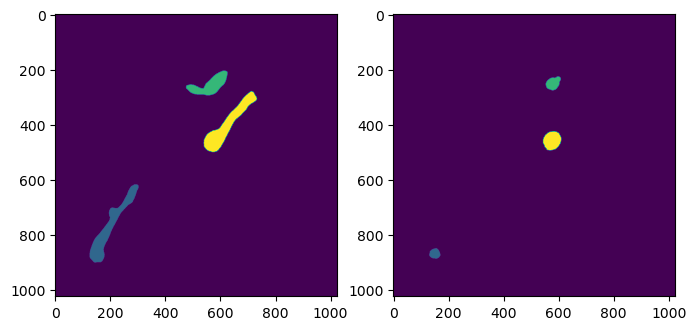

In [85]:
# Plot whole cell and nucleus mask side by side

fig, ax = plt.subplots(1, 2, figsize = (8,4))
ax[0].imshow(mask_cell[0])
ax[1].imshow(mask_nucleus[0])

In [86]:
# To match intensity values (= labels) of ROIs in nucleus image to intensity values of ROIs in whole cell image

for nucleus_image, cell_image in zip(mask_nucleus, mask_cell):
    # Create a dictionary to store coordinates and corresponding intensity values from mask_cell
    coordinates_intensity = {}

    # Store coordinates and intensity values from cell_image in the dictionary
    for cell_label in regionprops(cell_image):
        for coord in cell_label.coords:
            coordinates_intensity[tuple(coord)] = cell_image[coord[0], coord[1]]

    # Update nucleus_image based on the mapped coordinates and intensity values
    for nucleus_label in regionprops(nucleus_image):
        for coord in nucleus_label.coords:
            if tuple(coord) in coordinates_intensity:
                nucleus_image[coord[0], coord[1]] = coordinates_intensity[tuple(coord)]

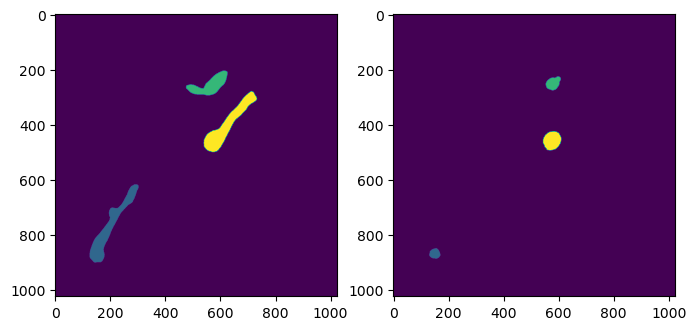

In [87]:
# Plot results of label matching

fig, ax = plt.subplots(1, 2, figsize = (8,4))
ax[0].imshow(mask_cell[0])
ax[1].imshow(mask_nucleus[0])

In [88]:
# Substract nucleus mask from cell mask and store as binary cytoplasm mask

mask_cytoplasm = []

for cell, nucleus in zip (mask_cell, mask_nucleus):
    image = skimage.util.compare_images(cell, nucleus)
    mask_cytoplasm.append(image)

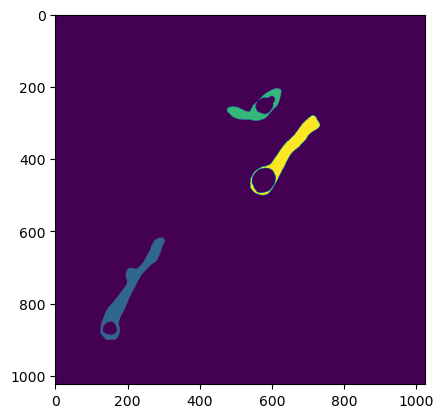

In [89]:
# Plot binary cytoplasm mask

plt.imshow(mask_cytoplasm[0])

In [90]:
np.unique(mask_cytoplasm[0])

array([0.        , 0.00392157, 0.00784314, 0.01176471])

In [91]:
# Converting ROI values to integers

mask_cytoplasm_int = []

for element in mask_cytoplasm:
    
    # Find unique values
    unique_values = np.unique(element)
    #print(unique_values)

    # Create a mapping dictionary
    mapping = {value: index for index, value in enumerate(unique_values)}

    # Replace values with integers
    int_array = np.array([[mapping[value] for value in row] for row in element])
    int_array = int_array.astype(float)
    
    mask_cytoplasm_int.append(int_array)
    

np.unique(mask_cytoplasm_int[0])

array([0., 1., 2., 3.])

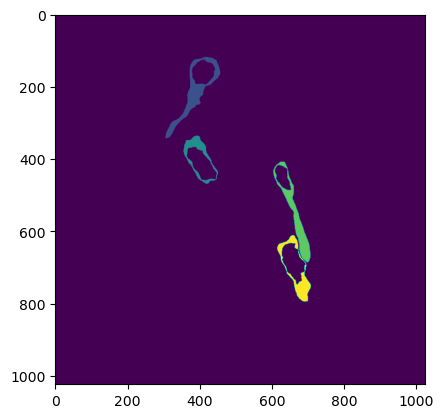

In [92]:
plt.imshow(mask_cytoplasm_int[2])

In [93]:
np.unique(mask_cytoplasm_int[2])

array([0., 1., 2., 3., 4.])

In [94]:
# print(mask_cytoplasm[2][100:110, 50:60])

In [95]:
print(type(mask_cytoplasm[2]))
print(type(mask_cytoplasm_int[2]))

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


In [96]:
# Save cytoplasm masks

mask_cytoplasm_dir = r'/Users/abamford/Desktop/TUBB2B-KI_preliminary_analysis/Batch20230922/D35/50ms/ROIs/Cytoplasm'


In [97]:
# Save mask images

for img, tiff_file in zip(mask_cytoplasm_int, mask_cell_files):
    
    # Extract the original file name without the extension
    file_name = os.path.splitext(os.path.basename(tiff_file))[0]
    print(file_name)
    
    # Define the output file path
    output_file = os.path.join(mask_cytoplasm_dir, file_name + '.tif')
    print(output_file)
    
    # Save the manipulated image as a TIFF
    tf.imwrite(output_file, img)

5_100tp_561-100-50ms-901g_1_conf561_ROIs
/Users/abamford/Desktop/TUBB2B-KI_preliminary_analysis/Batch20230922/D35/50ms/ROIs/Cytoplasm/5_100tp_561-100-50ms-901g_1_conf561_ROIs.tif
32_100tp_561-100-50ms-901g_1_conf561_ROIs
/Users/abamford/Desktop/TUBB2B-KI_preliminary_analysis/Batch20230922/D35/50ms/ROIs/Cytoplasm/32_100tp_561-100-50ms-901g_1_conf561_ROIs.tif
31_100tp_561-100-50ms-901g_1_conf561_xyCorrected_ROIs
/Users/abamford/Desktop/TUBB2B-KI_preliminary_analysis/Batch20230922/D35/50ms/ROIs/Cytoplasm/31_100tp_561-100-50ms-901g_1_conf561_xyCorrected_ROIs.tif
7_100tp_561-100-50ms-901g_1_conf561_ROIs
/Users/abamford/Desktop/TUBB2B-KI_preliminary_analysis/Batch20230922/D35/50ms/ROIs/Cytoplasm/7_100tp_561-100-50ms-901g_1_conf561_ROIs.tif
25_100tp_561-100-50ms-901g_1_conf561_xyCorrected_ROIs
/Users/abamford/Desktop/TUBB2B-KI_preliminary_analysis/Batch20230922/D35/50ms/ROIs/Cytoplasm/25_100tp_561-100-50ms-901g_1_conf561_xyCorrected_ROIs.tif
5-2_100tp_561-100-50ms-901g_1_conf561_xyCorrected_R